In [42]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.ticker as ticker

In [18]:
# ---------------------------------------
# paths
# ---------------------------------------
n_best=2440
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D_reduced.nc")
best1=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo1D.nc")

/tmp/ipykernel_3578770/3430036906.py:45: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
/tmp/ipykernel_3578770/3430036906.py:50: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%",
/tmp/ipykernel_3578770/3430036906.py:55: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_vol = inset_axes(ax_leg, width="75%", height="40%",


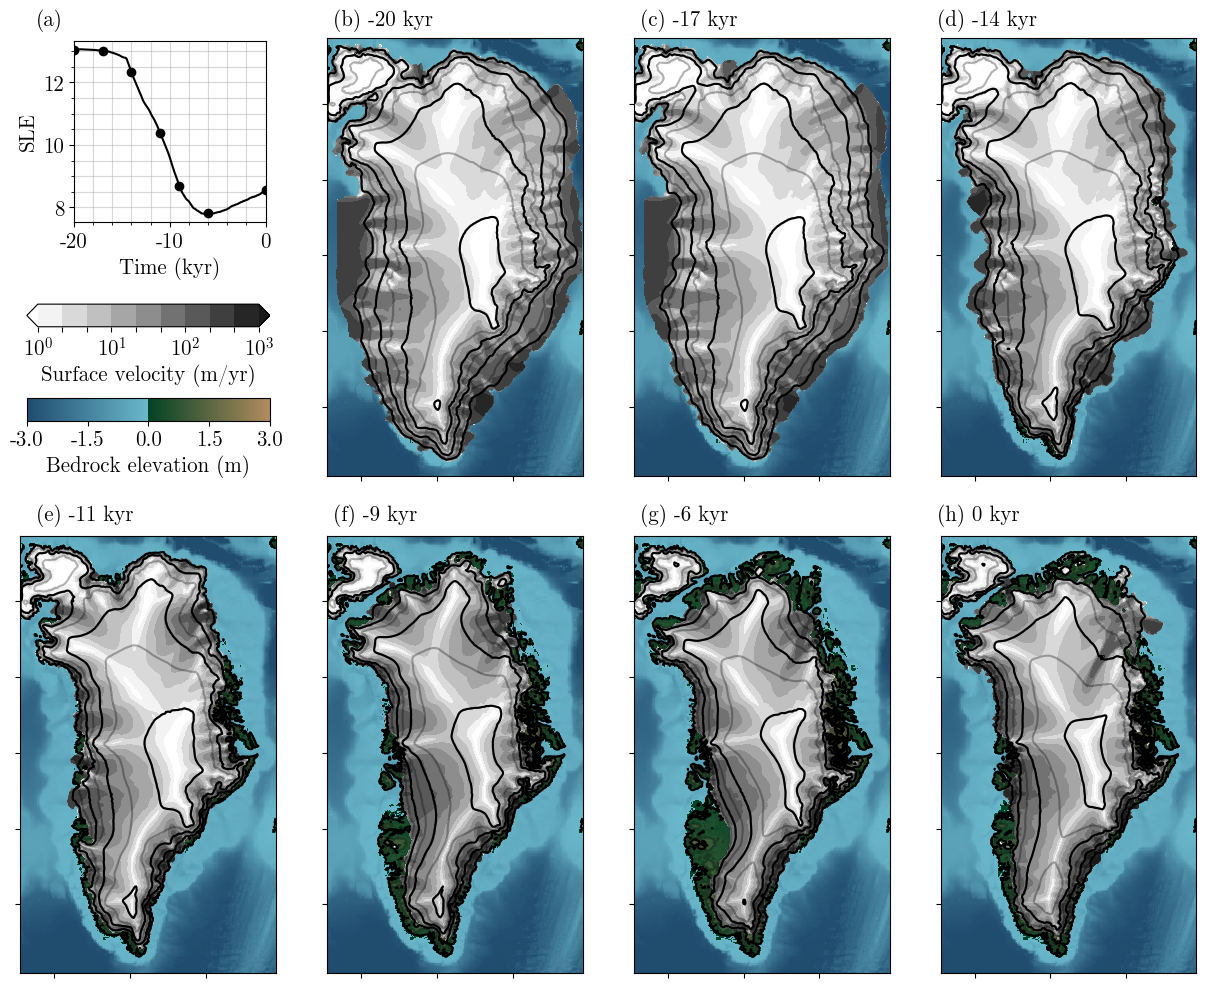

In [82]:
def pd_plot(ax,sim,uxy_s_map,zmap):
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    ice=xr.where((sim.f_grnd==1)&(sim.H_ice>0), 1, 0)
    log_uxy = sim.uxy_s.where(sim.H_ice>0) + 1e-8

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')
    # ice = ax.contourf(xc, yc, ice, colors=['White'],levels=np.linspace(0.5, 1.2, 2))

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')

    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return bat, vel

colors = ["#ffffff", "#a8a8a8", "#000000"]

# Crear un colormap interpolado con 10 niveles
uxy_s_map = truncate_colormap(plt.get_cmap('gray_r'), minval=0, maxval=0.9)

zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
(0.0, "#204c6e"),
(0.499, "#6ab8cb"),
(0.50, "#024224"),
(1.0, "#b18b5d")])

fig, axs=plt.subplots(2,4, figsize=(12,10))
times=[-20000,-17000,-14000,-11000,-9000,-6000,0]

for t in times:
    if t < times[3]: ax=axs[0,times.index(t)+1]
    else: ax=axs[1,times.index(t)-3]
    sim=best.sel(time=t)
    bed,vel=pd_plot(ax,sim,uxy_s_map,zmap)
        
# Leyenda
ax_leg=axs[0,0]
ax_leg.axis('off')
axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
bbox_transform=ax_leg.transAxes,borderpad=3)
cb = plt.colorbar(bed, cax=axins, orientation='horizontal', ticks=[-3,-1.5,0,1.5,3],shrink=0.5)
cb.set_label('Bedrock elevation (m)')

axins = inset_axes( ax_leg, width="95%", height="5%", 
loc="lower center", bbox_transform=ax_leg.transAxes,borderpad=7.5)
cb = plt.colorbar(vel, cax=axins, orientation='horizontal',shrink=0.5)
cb.set_label('Surface velocity (m/yr)')

ax_vol = inset_axes(ax_leg, width="75%", height="40%", 
loc="upper right", bbox_transform=ax_leg.transAxes)

ax_vol.plot(best1.time*1e-3, best1.V_sle, color='black')

for t in times:
    sim1=best1.sel(time=t)
    ax_vol.plot(sim1.time*1e-3, sim1.V_sle, marker='o', color='black')

ax_vol.set_xlabel('Time (kyr)')
ax_vol.set_ylabel('SLE')
ax_vol.xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax_vol.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax_vol.grid(which="both",alpha=0.5)
ax_vol.set_xlim(-20,0)

h=13.8

ax_vol.text(-24,h,"(a)")
ax_vol.text(7,h,f"(b) {int(times[0]*1e-3)} kyr")
ax_vol.text(39,h,f"(c) {int(times[1]*1e-3)} kyr")
ax_vol.text(70,h,f"(d) {int(times[2]*1e-3)} kyr")
h=-2
ax_vol.text(-24,h,f"(e) {int(times[3]*1e-3)} kyr")
ax_vol.text(7,h,f"(f) {int(times[4]*1e-3)} kyr")
ax_vol.text(39,h,f"(g) {int(times[5]*1e-3)} kyr")
ax_vol.text(70,h,f"(h) {int(times[6]*1e-3)} kyr")

plt.subplots_adjust(
        left=0.01,   
        right=0.99, 
        top=0.95,    
        bottom=0,  
        wspace=0.2,  
        hspace=0.1)
plt.savefig(f"../figs/best_ice_{n_best}.png",dpi=300)
# plt.close()
